# Identifying High-Value Customers for Marketing Campaigns

## Business Problem

The company is investing in marketing campaigns, but response rates are low and inconsistent. Currently, promotions are sent to a broad audience without a clear understanding of which customers are most likely to respond. This leads to inefficient use of marketing resources and missed opportunities to target high-value customers.

### Business Question

Which customer segments are most likely to respond to marketing campaigns, and how can the company target them more effectively?

In [51]:
import pandas as pd
import matplotlib.pyplot as plt


In [52]:
df = pd.read_csv("C:\\Users\\stell\\Downloads\\customer personality analysis\\marketing_campaign.csv", sep="\t")
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

## Data Exploration 

In [61]:
# Fill missing income values with a typical middle value so we keep all customers
df["Income"] = df["Income"].fillna(df["Income"].median())

# Convert customer enrollment date to datetime format
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

# Create a new column for customer age
df["Age"] = 2026 - df["Year_Birth"]

# Create total spending columns
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# Standardize marital status categories into "In relationship" and "Single"
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": "In relationship",
    "Together": "In relationship",
    "Divorced": "Single",
    "Widow": "Single",
    "Alone": "Single",
    "Absurd": "Single",
    "YOLO": "Single"
})

print(df[["Age", "Income", "Total_Spending"]].describe())



               Age         Income  Total_Spending
count  2240.000000    2240.000000     2240.000000
mean     57.194196   52237.975446      605.798214
std      11.984069   25037.955891      602.249288
min      30.000000    1730.000000        5.000000
25%      49.000000   35538.750000       68.750000
50%      56.000000   51381.500000      396.000000
75%      67.000000   68289.750000     1045.500000
max     133.000000  666666.000000     2525.000000


### Who are our customers?

I started by looking at how income is distributed across customers to understand what the typical customer looks like. The histogram shows that most customers fall within a middle-income range, with fewer at the higher end. This gives a baseline view of the customer base and helps set realistic expectations for targeting.

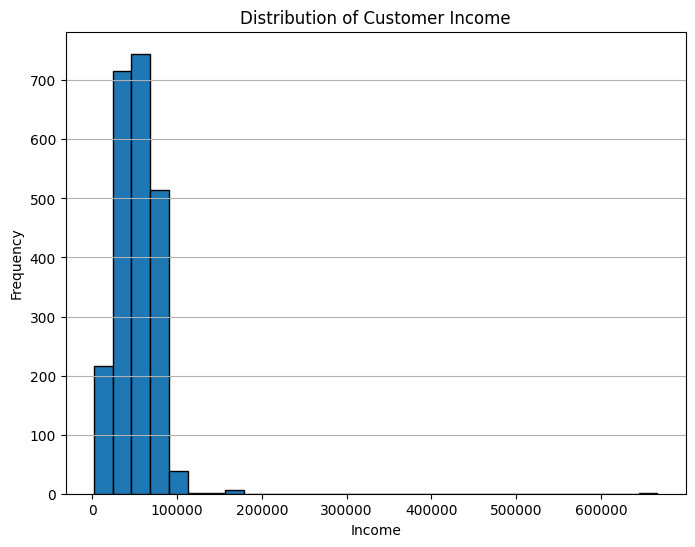

In [54]:
plt.figure(figsize=(8, 6))
plt.hist(df["Income"], bins=30, edgecolor="black")
plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

### Who spends the most?

Next, I looked at the relationship between income and total spending to identify higher-value customers. The scatter plot shows a general trend where higher-income customers tend to spend more, but there is still variation. This suggests that income is important, but not enough on its own to fully explain spending behavior.

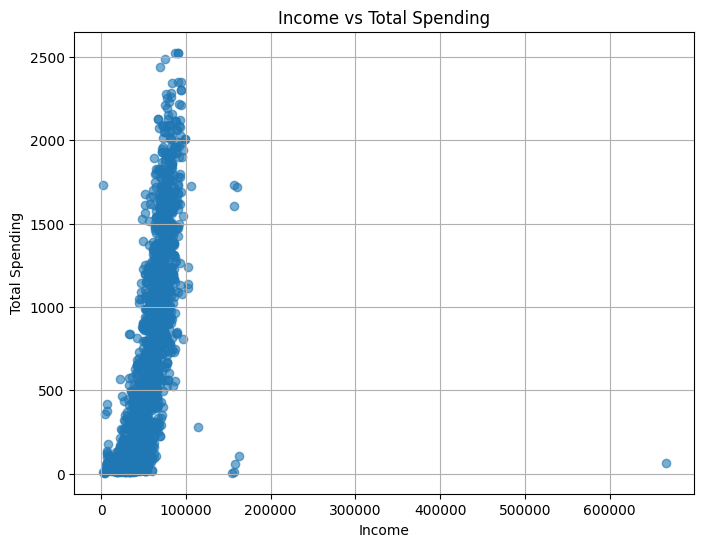

In [55]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Income"], df["Total_Spending"], alpha=0.6)
plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.grid(True)
plt.show()

### Which groups stand out?

I then compared average spending across different customer groups to see if certain segments stand out. The bar chart shows that some groups spend more on average than others, which suggests that customer behavior varies across segments. This helps narrow down which types of customers may be more valuable to target.

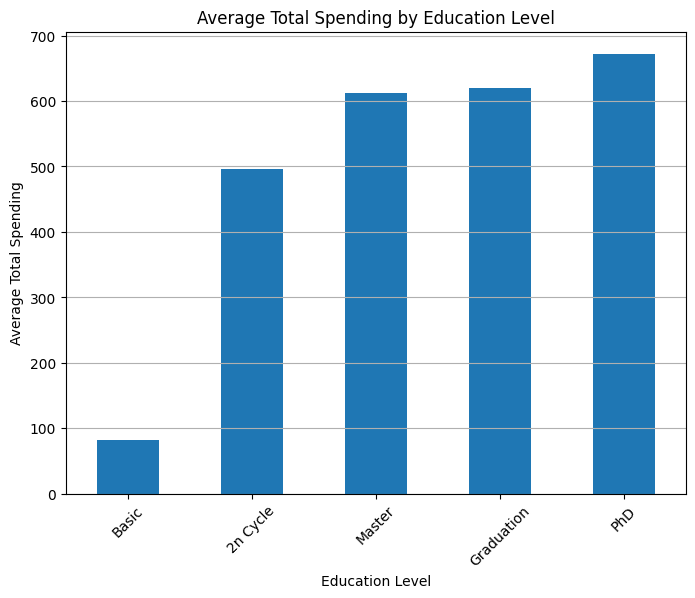

In [56]:
avg_spending_by_education = df.groupby("Education")["Total_Spending"].mean().sort_values()

plt.figure(figsize=(8, 6))
avg_spending_by_education.plot(kind="bar")
plt.title("Average Total Spending by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

### Do high-value customers actually respond?

After identifying higher-value customers, I wanted to see if they are also more likely to respond to marketing campaigns. This chart compares the average spending of customers who responded versus those who did not.

If customers who responded tend to spend more, it suggests that targeting high-value customers could improve campaign effectiveness. If there is little difference, it shows that spending alone may not predict response, and other factors need to be considered.

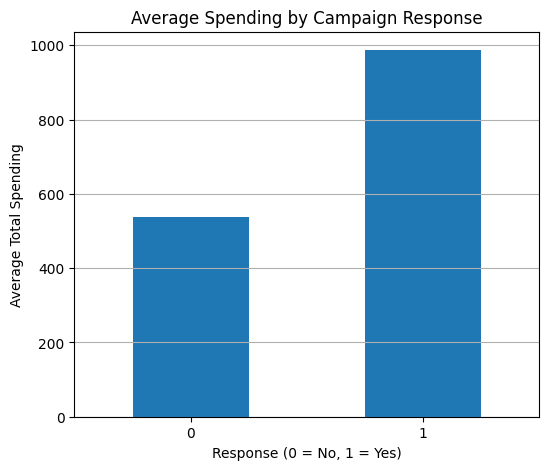

In [57]:
# Average spending by campaign response
response_spending = df.groupby("Response")["Total_Spending"].mean()

plt.figure(figsize=(6, 5))
response_spending.plot(kind="bar")
plt.title("Average Spending by Campaign Response")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

### Do lifestyle factors matter?

Finally, I looked at how household structure might influence behavior by considering both the number of children in a household and whether a customer is single or partnered. This adds another layer beyond just income and spending, and the charts show that response can vary across these groups. This suggests that customer behavior is shaped by more than just financial factors and that marketing strategies should consider lifestyle differences, not just income.

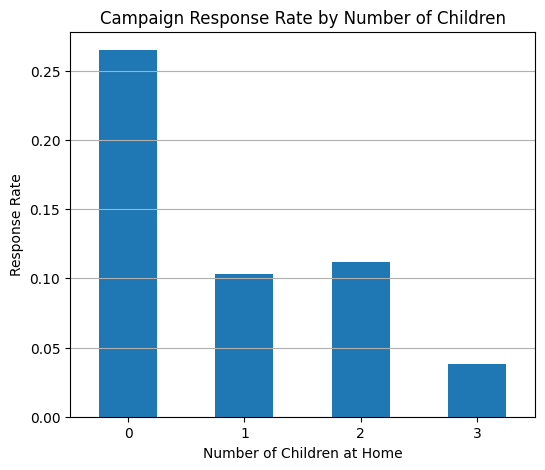

In [58]:
df["Children"] = df["Kidhome"] + df["Teenhome"]

children_response = df.groupby("Children")["Response"].mean()

plt.figure(figsize=(6, 5))
children_response.plot(kind="bar")
plt.title("Campaign Response Rate by Number of Children")
plt.xlabel("Number of Children at Home")
plt.ylabel("Response Rate")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

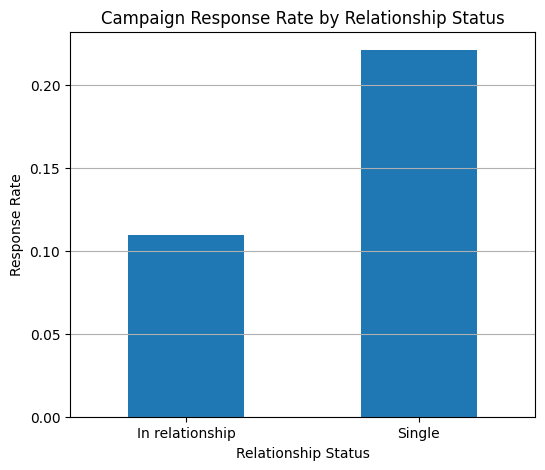

In [63]:
relationship_response = df.groupby("Marital_Status")["Response"].mean()

plt.figure(figsize=(6, 5))
relationship_response.plot(kind="bar")
plt.title("Campaign Response Rate by Relationship Status")
plt.xlabel("Relationship Status")
plt.ylabel("Response Rate")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

### Final Insights

From this analysis, income and spending help identify higher-value customers, but they don’t fully explain who responds to campaigns. While some higher spenders do engage more, the pattern is not consistent across all customers. Response rates are higher among customers who are single and have no children, which shows that behavior is influenced by lifestyle factors, not just spending. This suggests that treating all customers the same is not effective, and a more targeted approach that considers both spending and customer characteristics would likely improve response rates and make marketing efforts more efficient.